# Embedding filters 6 — summary & benchmark

Seven recursive estimators for a tracker's appearance embedding, all
behind the same `State` interface. This notebook puts them
side-by-side on **compute** (FLOPs + wall-clock, and how they scale
with the embedding dimension `D`), **accuracy** (on two
complementary tasks), and **effort** (tuning / training), and ends
with a fail/success cheat-sheet.

| Method | one-line idea |
|---|---|
| EMA | constant-gain blend (steady-state scalar Kalman) |
| diagonal Kalman | random-walk Kalman, adaptive gain |
| vMF | recursive Bayes on the unit sphere |
| information filter | exact Kalman dual; additive fusion |
| EnKF | covariance via an ensemble (built for large `D`) |
| gallery | feature bank of the last `K` views |
| learned | MOTR-style module trained through the association |

**Methodology.** Compute is measured on the *state update* in
isolation (the matching cost is shared). Accuracy is measured on two
tasks because no single number is fair to all: a **denoising** task
(smooth a drifting embedding) and an **association-under-fast-motion**
task (keep four rotating identities matched). Each method is set to a
reasonable operating point — and *finding* that point is itself part
of the "effort" comparison (vMF needs its decay tuned; the EnKF needs
enough inflation or its ensemble collapses).


In [ ]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker, sinkhorn_log_plan
from unitrack.costs import Cosine, GalleryCost
from unitrack.data import (
    Detections,
    FrameContext,
    MatchOutcome,
    TensorSpec,
    Tracklets,
)
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe
from unitrack.states import (
    EMAFuse,
    EMATrack,
    FromDetectionField,
    Identity,
    LearnedObservation,
    LearnedProcess,
    NoopObservation,
    NoopProcess,
    Replace,
    State,
    EyeInitializer,
    vmf_state_entries,
    gallery_state_entries,
)
from unitrack.states.kalman import (
    KalmanLinear,
    KalmanUpdate,
    enkf_state_entries,
    information_state_entries,
)

torch.manual_seed(0)


def _reserved(n):
    return dict(
        id=torch.arange(n),
        status=torch.full((n,), 1, dtype=torch.int8),
        hits=torch.ones(n, dtype=torch.int32),
        time_since_update=torch.zeros(n, dtype=torch.int32),
        age=torch.ones(n, dtype=torch.int32),
        frame_started=torch.zeros(n, dtype=torch.int32),
        frame_last_seen=torch.zeros(n, dtype=torch.int32),
    )


def spawn(states, n, dim):
    ds = Detections(index=torch.arange(n), emb=torch.randn(n, dim), batch_size=[n])
    user = {k: st.init(ds, FrameContext.make(0)) for k, st in states.items()}
    return Tracklets(**_reserved(n), **user, batch_size=[n]), ds


def match_n(n):
    p = torch.stack([torch.arange(n), torch.arange(n)], 1)
    return MatchOutcome(
        matched_pairs=p,
        tracklets_residual_index=torch.zeros(0, dtype=torch.int64),
        detections_residual_index=torch.zeros(0, dtype=torch.int64),
        per_match_cost=torch.zeros(n),
        batch_size=[],
    )


def step_update(states, cs, ds, m, ctx):
    out = cs
    for st in states.values():
        out = st.process(out, ctx)
    for st in states.values():
        out = st.observation(out, ds, m, ctx)
    return out


def time_us(fn, iters=40, warmup=5):
    for _ in range(warmup):
        fn()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    return (time.perf_counter() - t0) / iters * 1e6


In [ ]:
# Method registry: a factory (states at dim D) + metadata, each at a
# reasonable operating point (see the per-method notebooks).
def st_ema(D):
    return {
        "emb": State(
            TensorSpec((D,), torch.float32),
            EMATrack("emb"),
            EMAFuse("emb", 0.8),
            FromDetectionField("emb"),
        )
    }


def st_kalman(D):
    e = torch.eye(D)
    return {
        "emb": State(
            TensorSpec((D,), torch.float32),
            KalmanLinear("emb", e, e, e * 0.02, e * 0.2),
            KalmanUpdate("emb", "emb_cov", e, e * 0.2),
            FromDetectionField("emb"),
        ),
        "emb_cov": State(
            TensorSpec((D, D), torch.float32),
            NoopProcess(),
            NoopObservation(),
            EyeInitializer(D, 1.0),
        ),
    }


def st_vmf(D):
    return vmf_state_entries("emb", dim=D, init_kappa=3.0, kappa_obs=5.0, tau=3.0)


def st_info(D):
    return information_state_entries("emb", dim=D, q=0.02, r=0.2)


def st_enkf(D):
    return enkf_state_entries(
        "emb", dim=D, ensemble_size=32, q=1.0, r=0.2, init_std=0.5
    )


def st_gallery(D):
    return gallery_state_entries("emb", dim=D, capacity=8)


def st_learned(D):
    prop = nn.Sequential(nn.Linear(D, 64), nn.Tanh(), nn.Linear(64, D))
    fuse = nn.Sequential(nn.Linear(2 * D, 64), nn.Tanh(), nn.Linear(64, D))
    nrm = torch.nn.functional.normalize
    return {
        "emb": State(
            TensorSpec((D,), torch.float32),
            LearnedProcess("emb", lambda x, dt: nrm(x + prop(x), dim=-1)),
            LearnedObservation(
                "emb",
                "emb",
                lambda tr, me: nrm(tr + fuse(torch.cat([tr, me], -1)), dim=-1),
            ),
            FromDetectionField("emb"),
        )
    }


METHODS = {
    "EMA": dict(make=st_ema, flops="2·N·D", effort=1),
    "diag-Kalman": dict(make=st_kalman, flops="~N·D³ (dense)", effort=2),
    "vMF": dict(make=st_vmf, flops="~4·N·D", effort=3),
    "info-filter": dict(make=st_info, flops="~N·D³", effort=3),
    "EnKF (E=32)": dict(make=st_enkf, flops="N·(E²D+E³)", effort=4),
    "gallery (K=8)": dict(make=st_gallery, flops="N·D  (+K·matching)", effort=2),
    "learned": dict(make=st_learned, flops="2·N·D·H  (+train)", effort=5),
}
print("methods:", list(METHODS))


methods: ['EMA', 'diag-Kalman', 'vMF', 'info-filter', 'EnKF (E=32)', 'gallery (K=8)', 'learned']


## 1 — Compute: FLOPs and how they scale with `D`

The dominant FLOPs of one **state update** (`N` tracks, `D` dims;
`E` ensemble members, `K` gallery slots, `H` MLP width). The split is
the whole point: the dense Gaussian filters are `O(D³)` per update
(a `D×D` solve), which is fine at `D=16` but ruinous at the `D=256+`
of a real ReID/DETR embedding. EMA, vMF and the learned MLP are
`O(D)`; the EnKF trades the `D³` for `E²D+E³`, paying off once
`E ≪ D`.


state-update cost at D=256, N=8:
  EMA            2·N·D                       56.0 us
  diag-Kalman    ~N·D³ (dense)            22393.3 us
  vMF            ~4·N·D                     359.5 us
  info-filter    ~N·D³                     9634.7 us
  EnKF (E=32)    N·(E²D+E³)                2147.4 us
  gallery (K=8)  N·D  (+K·matching)         215.8 us
  learned        2·N·D·H  (+train)          498.1 us


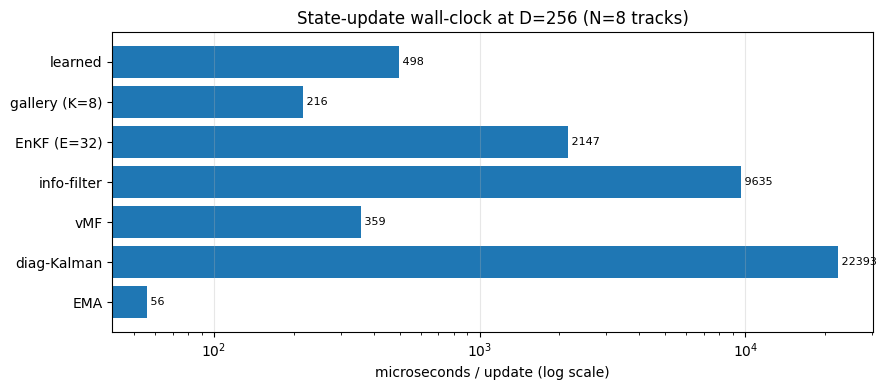

In [ ]:
D_BENCH, N_BENCH = 256, 8
rows = []
with torch.no_grad():
    for name, meta in METHODS.items():
        st = meta["make"](D_BENCH)
        cs, ds = spawn(st, N_BENCH, D_BENCH)
        m = match_n(N_BENCH)
        ctx = FrameContext.make(1, delta=1.0)
        meta["us256"] = time_us(
            lambda st=st, cs=cs, ds=ds, m=m, ctx=ctx: step_update(st, cs, ds, m, ctx)
        )
        rows.append((name, meta["flops"], meta["us256"]))
print(f"state-update cost at D={D_BENCH}, N={N_BENCH}:")
for n, f, u in rows:
    print(f"  {n:14s} {f:22s} {u:9.1f} us")

fig, ax = plt.subplots(figsize=(9, 4))
names = [r[0] for r in rows]
us = [r[2] for r in rows]
ax.barh(names, us, color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("microseconds / update (log scale)")
ax.set_title(f"State-update wall-clock at D={D_BENCH} (N={N_BENCH} tracks)")
for i, u in enumerate(us):
    ax.text(u, i, f" {u:.0f}", va="center", fontsize=8)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


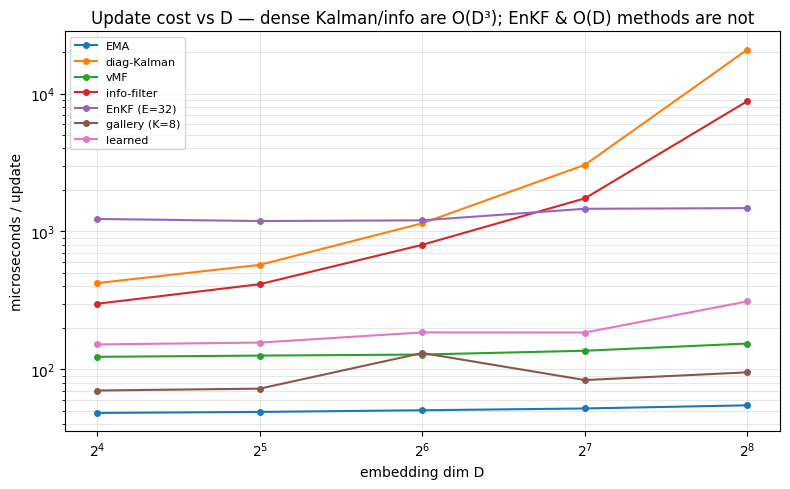

In [ ]:
# Scaling with D: the O(D^3) filters curve up; the rest stay flat.
DIMS = [16, 32, 64, 128, 256]
curves = {name: [] for name in METHODS}
with torch.no_grad():
    for D in DIMS:
        for name, meta in METHODS.items():
            st = meta["make"](D)
            cs, ds = spawn(st, N_BENCH, D)
            m = match_n(N_BENCH)
            ctx = FrameContext.make(1, delta=1.0)
            curves[name].append(
                time_us(
                    lambda st=st, cs=cs, ds=ds, m=m, ctx=ctx: step_update(
                        st, cs, ds, m, ctx
                    ),
                    iters=25,
                )
            )
fig, ax = plt.subplots(figsize=(8, 5))
for name, ys in curves.items():
    ax.plot(DIMS, ys, "o-", ms=4, label=name)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("embedding dim D")
ax.set_ylabel("microseconds / update")
ax.set_title(
    "Update cost vs D — dense Kalman/info are O(D³); EnKF & O(D) methods are not"
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


Two honest caveats the benchmark exposes:

- The shipped **diagonal Kalman** uses the generic dense
  `KalmanLinear`, so it is `O(D³)` here. A diagonal-specialised
  implementation would be `O(D)` — the *math* is cheap, the generic
  *code* is not.
- The **gallery**'s update is trivial (`O(D)` append); its real cost
  is in *matching*, where `GalleryCost` compares against `K` stored
  views — `K×` an ordinary cosine. We measure that separately:


In [ ]:
D, N, M, K = 256, 8, 8, 8
gst = st_gallery(D)
gcs, _ = spawn(gst, N, D)
dets = Detections(index=torch.arange(M), emb=torch.randn(M, D), batch_size=[M])
ctx = FrameContext.make(0)
cos = Cosine("emb")
gcost = GalleryCost("emb_gallery", "emb_count", "emb")
t_cos = time_us(lambda: cos(gcs, dets, ctx))
t_gal = time_us(lambda: gcost(gcs, dets, ctx))
print(
    f"matching {N}x{M} at D={D}:  Cosine {t_cos:.1f} us   "
    f"GalleryCost(K={K}) {t_gal:.1f} us   ({t_gal / t_cos:.1f}x)"
)


matching 8x8 at D=256:  Cosine 69.7 us   GalleryCost(K=8) 312.8 us   (4.5x)


## 2 — Accuracy on two complementary tasks

**Denoising** (smooth a drifting embedding): the genuine smoothers do
well; the **gallery** sits at the raw level because it stores views
rather than averaging them (it is memory, not a smoother), and
**learned** is not built for this. **Association under fast motion**
(four identities rotating ~54°/frame): every static filter lags into
its neighbour and mis-associates; only the **learned** module, trained
through the differentiable matcher, anticipates the motion.


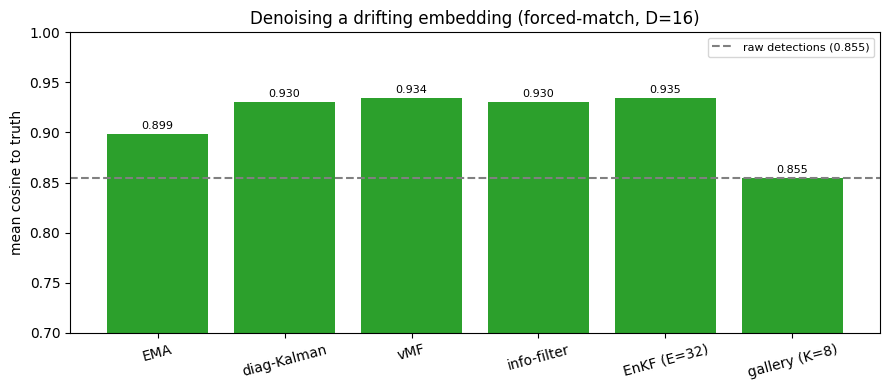

In [ ]:
D = 16


def dn_clip(T=44, noise=0.15, seed=0):
    g = torch.Generator().manual_seed(seed)
    t = torch.arange(T).float()
    th = 0.10 * t
    truth = torch.zeros(T, D)
    truth[:, 0] = torch.cos(th)
    truth[:, 1] = torch.sin(th)
    obs = torch.nn.functional.normalize(
        truth + noise * torch.randn(T, D, generator=g), dim=-1
    )
    return truth, obs


def denoise_cos(states):
    """Forced-match single-track driver: isolates filter quality from matching."""
    truth, obs = dn_clip()
    d0 = Detections(index=torch.tensor([0]), emb=obs[0:1].clone(), batch_size=[1])
    cs = Tracklets(
        **_reserved(1),
        **{k: st.init(d0, FrameContext.make(0)) for k, st in states.items()},
        batch_size=[1],
    )
    m = match_n(1)
    coss = []
    for k in range(1, len(obs)):
        ctx = FrameContext.make(k, delta=1.0)
        for st in states.values():
            cs = st.process(cs, ctx)
        ds = Detections(
            index=torch.tensor([0]), emb=obs[k : k + 1].clone(), batch_size=[1]
        )
        for st in states.values():
            cs = st.observation(cs, ds, m, ctx)
        coss.append((torch.nn.functional.normalize(cs.emb[0], dim=0) @ truth[k]).item())
    return sum(coss) / len(coss)


truth, obs = dn_clip()
raw = (torch.nn.functional.normalize(obs, dim=-1) * truth).sum(-1).mean().item()
denoise = {}
with torch.no_grad():
    for name in [
        "EMA",
        "diag-Kalman",
        "vMF",
        "info-filter",
        "EnKF (E=32)",
        "gallery (K=8)",
    ]:
        denoise[name] = denoise_cos(METHODS[name]["make"](D))
METHODS_denoise = denoise
fig, ax = plt.subplots(figsize=(9, 4))
names = list(denoise)
vals = [denoise[n] for n in names]
ax.bar(names, vals, color="tab:green")
ax.axhline(raw, ls="--", color="0.5", label=f"raw detections ({raw:.3f})")
ax.set_ylim(0.7, 1.0)
ax.set_ylabel("mean cosine to truth")
ax.set_title("Denoising a drifting embedding (forced-match, D=16)")
ax.legend(fontsize=8)
plt.xticks(rotation=15)
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


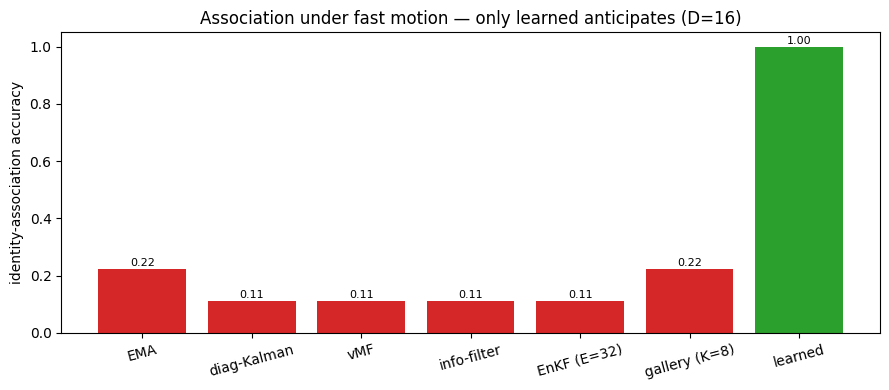

In [ ]:
# Association task: rotate fast; learned anticipates, statics lag.
N, RT, OM, NZ = 4, 10, 0.95, 0.10


def rot_clip(seed, shuffle=True):
    g = torch.Generator().manual_seed(seed)
    ph = torch.arange(N).float() * (2 * torch.pi / N)
    frames, gts = [], []
    for k in range(RT):
        a = ph + OM * k
        e = torch.zeros(N, D)
        e[:, 0] = torch.cos(a)
        e[:, 1] = torch.sin(a)
        e = torch.nn.functional.normalize(
            e + NZ * torch.randn(N, D, generator=g), dim=-1
        )
        order = torch.randperm(N, generator=g) if shuffle else torch.arange(N)
        frames.append(e[order])
        gt = torch.empty(N, dtype=torch.long)
        gt[order] = torch.arange(N)
        gts.append(gt)
    return frames, gts


def assoc_acc(states):
    tr = unitrack.Tracker(
        root=Pipe(cost=Cosine("emb"), assoc=Associate(Jonker(threshold=0.95))),
        states=states,
        lifecycle=NoLifecycle(),
        visibility=IncludeAll(),
    )
    ms = unitrack.MultiStream(tr)
    frames, _ = rot_clip(99, shuffle=False)
    c = t = 0
    for k in range(RT):
        d = Detections(index=torch.arange(N), emb=frames[k].clone(), batch_size=[N])
        res = ms.step(
            stream_key=0,
            detections=d,
            ctx=FrameContext.make(k, delta=1.0, stream_key=0),
        )
        if k > 0:
            p = res.match.matched_pairs
            c += int((p[:, 0] == p[:, 1]).sum())
            t += p.shape[0]
    return c / max(t, 1)


# Train the learned propagator/fuser through the soft association (MOTR-style).
def cosdist(a, b):
    a = torch.nn.functional.normalize(a, dim=-1)
    b = torch.nn.functional.normalize(b, dim=-1)
    return 1.0 - a @ b.T


prop = nn.Sequential(nn.Linear(D, 64), nn.Tanh(), nn.Linear(64, D))
fuse = nn.Sequential(nn.Linear(2 * D, 64), nn.Tanh(), nn.Linear(64, D))
nrm = torch.nn.functional.normalize
pf = lambda x: nrm(x + prop(x), dim=-1)
ff = lambda tr, me: nrm(tr + fuse(torch.cat([tr, me], -1)), dim=-1)
opt = torch.optim.Adam(list(prop.parameters()) + list(fuse.parameters()), lr=3e-3)
for epoch in range(150):
    frames, gts = rot_clip(epoch)
    track = frames[0][gts[0]].clone()
    loss = 0.0
    for k in range(1, RT):
        pred = pf(track)
        logP = sinkhorn_log_plan(cosdist(pred, frames[k]), epsilon=0.05, num_iter=50)
        loss = loss - logP[torch.arange(N), gts[k]].mean()
        track = ff(pred, frames[k][gts[k]])
    opt.zero_grad()
    (loss / (RT - 1)).backward()
    opt.step()

learned_states = {
    "emb": State(
        TensorSpec((D,), torch.float32),
        LearnedProcess("emb", lambda x, dt: pf(x)),
        LearnedObservation("emb", "emb", ff),
        FromDetectionField("emb"),
    )
}

assoc = {}
with torch.no_grad():
    for name in [
        "EMA",
        "diag-Kalman",
        "vMF",
        "info-filter",
        "EnKF (E=32)",
        "gallery (K=8)",
    ]:
        assoc[name] = assoc_acc(METHODS[name]["make"](D))
    assoc["learned"] = assoc_acc(learned_states)
fig, ax = plt.subplots(figsize=(9, 4))
names = list(assoc)
vals = [assoc[n] for n in names]
cols = ["tab:red" if v < 0.5 else "tab:green" for v in vals]
ax.bar(names, vals, color=cols)
ax.set_ylim(0, 1.05)
ax.set_ylabel("identity-association accuracy")
ax.set_title("Association under fast motion — only learned anticipates (D=16)")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


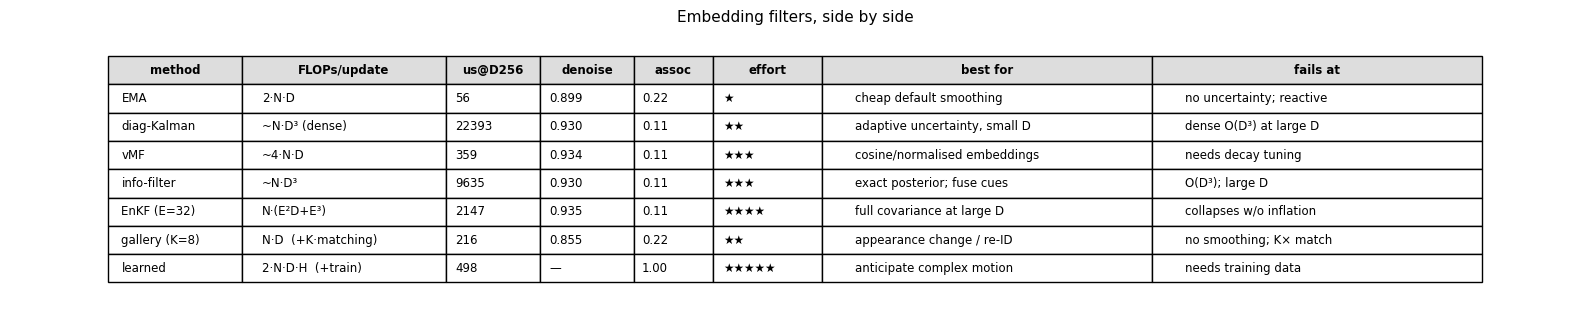

In [ ]:
# ---- the side-by-side table ----
FAILSUCCESS = {
    "EMA": ("cheap default smoothing", "no uncertainty; reactive"),
    "diag-Kalman": ("adaptive uncertainty, small D", "dense O(D³) at large D"),
    "vMF": ("cosine/normalised embeddings", "needs decay tuning"),
    "info-filter": ("exact posterior; fuse cues", "O(D³); large D"),
    "EnKF (E=32)": ("full covariance at large D", "collapses w/o inflation"),
    "gallery (K=8)": ("appearance change / re-ID", "no smoothing; K× match"),
    "learned": ("anticipate complex motion", "needs training data"),
}
order = [
    "EMA",
    "diag-Kalman",
    "vMF",
    "info-filter",
    "EnKF (E=32)",
    "gallery (K=8)",
    "learned",
]
header = [
    "method",
    "FLOPs/update",
    "us@D256",
    "denoise",
    "assoc",
    "effort",
    "best for",
    "fails at",
]
cells = []
for n in order:
    cells.append(
        [
            n,
            METHODS[n]["flops"],
            f"{METHODS[n]['us256']:.0f}",
            f"{METHODS_denoise.get(n, float('nan')):.3f}"
            if n in METHODS_denoise
            else "—",
            f"{assoc.get(n, float('nan')):.2f}" if n in assoc else "—",
            "★" * METHODS[n]["effort"],
            FAILSUCCESS[n][0],
            FAILSUCCESS[n][1],
        ]
    )
fig, ax = plt.subplots(figsize=(16, 3.2))
ax.axis("off")
tbl = ax.table(
    cellText=cells,
    colLabels=header,
    loc="center",
    cellLoc="left",
    colWidths=[0.085, 0.13, 0.06, 0.06, 0.05, 0.07, 0.21, 0.21],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.6)
for j in range(len(header)):
    tbl[0, j].set_facecolor("#dddddd")
    tbl[0, j].set_text_props(weight="bold")
ax.set_title("Embedding filters, side by side", fontsize=11, pad=12)
plt.tight_layout()
plt.show()


## How to choose

- **Default to EMA.** Cheapest, robust, one knob. Reach further only
  when it isn't enough.
- Want **calibrated uncertainty** (for gating) and `D` is small →
  **diagonal Kalman** or the **information filter** (exact, and the
  IF fuses many cues by addition).
- Embeddings are **cosine-normalised** and you want a confidence →
  **vMF** (just tune the decay to the drift rate).
- `D` is **large** and you still want covariance → **EnKF** (give it
  enough inflation), the only `O(D)`-friendly full-covariance option.
- Appearance **changes / re-ID gaps** → a **gallery**; it does not
  smooth, it remembers.
- Motion is **complex and you have data** → a **learned** module,
  trained through the association — the only method that anticipates
  rather than reacts, at the cost of a training pipeline.

No method dominates: the dense filters denoise best but don't scale;
the EnKF scales but must be inflated; the gallery and learned modules
win tasks the smoothers structurally cannot. The shared `State`
interface means you can swap among them — or compose them — without
touching the rest of the tracker.
